# DFT atom

In [1]:
using Pkg;

Pkg.activate("../.");

using SchrodingerEquationSolver
using SchrodingerEquationSolver:   Potentials, MathUtils, Hydrogen, InitialConditions,
                                   IntegralNumericalMethods, OneDSchrodingerEquationSolver,
                                   EigenvalueFinders
using Plots
using CSV
using DataFrames
using PrettyTables
using Libxc

  Activating project at `~/Desktop/physics_coding_projects/julia/SchrodingerEquationSolver`


In [2]:
##TEST FOR EIGENVALUE PROBLEM
Z=1;
r_max= 25.0;
grid_stru= Grids.ExponentialGrid(r_max, Z);
grid= grid_stru.grid;
l=0;
v_effe =(
    Potentials.angular_potential(l, grid) .+
    Potentials.coulomb_potential(Z, grid));
initial_condition_function_x_min = InitialConditions.atom_like_poly_at_r_min;
initial_condition_function_x_max = InitialConditions.exponential_decay_at_r_ref;
E_min= -Z^2/(2*1^2) - 0.5;
E_max= -Z^2/(2*3^2) + 0.005;
E_grid_stru= Grids.UniformGrid(E_min, E_max, 100);
energy_grid= E_grid_stru.grid;
eigen_inter= EigenvalueFinders.find_eigenvalue_intervals(energy_grid,v_effe, grid_stru, 
    initial_condition_function_x_min,
    initial_condition_function_x_max,
    l)
for elem in eigen_inter
    println("E_min= ", elem[1], " E_max= ", elem[2]);
end

UndefVarError: UndefVarError: `E_grid_stru` not defined

In [ ]:

##TEST FOR EIGENVALUE PROBLEM
Z=1;
r_max= 25.0;
grid_stru= Grids.ExponentialGrid(r_max, Z);
grid=grid_stru.grid;
l=0;
v_effe =(
    Potentials.angular_potential(l, grid) .+
    Potentials.coulomb_potential(Z, grid));
r_min=grid_stru.grid[1];
u1, w1 = InitialConditions.atom_like_poly_at_r_min(r_min,l=l);
E_min= -Z^2/(2*1^2) - 0.5;
E_max= -Z^2/(2*3^2) + 0.005;
E_grid_stru= Grids.UniformGrid(E_min, E_max, 100);
merge_value_list= zeros(length(E_grid_stru.grid));
for (i, E) in enumerate(E_grid_stru.grid)
    u_end, w_end=InitialConditions.exponential_decay_at_r_ref(r_max, E=E);
    u_merged, merge_value, merge_ratio=OneDSchrodingerEquationSolver.solver_uniform_integer_grid(E, u1, w1, u_end, w_end, 
    v_effe, grid_stru);
    merge_value_list[i] = merge_value;
end
ener_indx= MathUtils.indices_of_zeros_finder(merge_value_list);
#clean the potential eigenvalue segments
ener_indx_indicator= zeros(length(ener_indx));
for (i,indx) in enumerate(ener_indx)
    delta_E= E_grid_stru.grid[indx] - E_grid_stru.grid[indx-1];
    delta_x= merge_value_list[indx] - merge_value_list[indx-1];
    log_slop= log10(abs(delta_x)/abs(delta_E));
    if floor(log_slop) < 1.1
        ener_indx_indicator[i]=1;
        println("E= ", E_grid_stru.grid[indx],  " E_1= ", E_grid_stru.grid[indx-1], " merge_value= ", merge_value_list[indx]);
    end
end
#produce eigenvalues only for the good segments
    

E= -0.5013019079685745 E_1= -0.510892255892256 merge_value= 0.008778465289793591
E= -0.12727833894500562 E_1= -0.1368686868686868 merge_value= 0.042535080364069694
E= -0.06014590347923676 E_1= -0.06973625140291806 merge_value= 0.11869783751643906


In [ ]:
##TEST FOR EIGENVALUE PROBLEM
Z=1;
r_max= 25.0;
grid_stru= Grids.ExponentialGrid(r_max, Z);
grid=grid_stru.grid;
l=0;
v_effe =(
    Potentials.angular_potential(l, grid) .+
    Potentials.coulomb_potential(Z, grid));
r_min=grid_stru.grid[1];
u1, w1 = InitialConditions.atom_like_poly_at_r_min(r_min,l=l);
E_min= -Z^2/(2*1^2) - 0.5;
E_max= -Z^2/(2*3^2) + 0.005;
E_grid_stru= Grids.UniformGrid(E_min, E_max, 100);
merge_value_list= zeros(length(E_grid_stru.grid));
for (i, E) in enumerate(E_grid_stru.grid)
    u_end, w_end=InitialConditions.exponential_decay_at_r_ref(r_max, E=E);
    u_merged, merge_value, merge_ratio=OneDSchrodingerEquationSolver.solver_uniform_integer_grid(E, u1, w1, u_end, w_end, 
    v_effe, grid_stru);
    merge_value_list[i] = merge_value;
end
ener_indx= MathUtils.indices_of_zeros_finder(merge_value_list);
#clean the potential eigenvalue segments
ener_indx_indicator= zeros(length(ener_indx));
for (i,indx) in enumerate(ener_indx)
    delta_E= E_grid_stru.grid[indx] - E_grid_stru.grid[indx-1];
    delta_x= merge_value_list[indx] - merge_value_list[indx-1];
    log_slop= log10(abs(delta_x)/abs(delta_E));
    if floor(log_slop) < 1.1
        ener_indx_indicator[i]=1;
        println("E= ", E_grid_stru.grid[indx],  " E_1= ", E_grid_stru.grid[indx-1], " merge_value= ", merge_value_list[indx]);
    end
end
#produce eigenvalues only for the good segments
    

E= -0.5013019079685745 E_1= -0.510892255892256 merge_value= 0.008778465289793591
E= -0.12727833894500562 E_1= -0.1368686868686868 merge_value= 0.042535080364069694
E= -0.06014590347923676 E_1= -0.06973625140291806 merge_value= 0.11869783751643906


In [6]:
for indx in ener_indx
    delta_E= E_grid_stru.grid[indx] - E_grid_stru.grid[indx-1];
    delta_x= merge_value_list[indx] - merge_value_list[indx-1];
    log_slop= log10(abs(delta_x)/abs(delta_E));
    println("E= ", E_grid_stru.grid[indx], " merge_value= ", merge_value_list[indx], " slope= ", floor(log_slop));
end
    

E= -0.5013019079685745 merge_value= 0.008778465289793591 slope= 0.0
E= -0.37662738496071824 merge_value= -32.11680511839575 slope= 3.0
E= -0.12727833894500562 merge_value= 0.042535080364069694 slope= 1.0
E= -0.10809764309764303 merge_value= -4.338653799171228 slope= 2.0
E= -0.06014590347923676 merge_value= 0.11869783751643906 slope= 1.0


In [5]:
merge_value_list[ener_indx]

5-element Vector{Float64}:
   0.008778465289793591
 -32.11680511839575
   0.042535080364069694
  -4.338653799171228
   0.11869783751643906

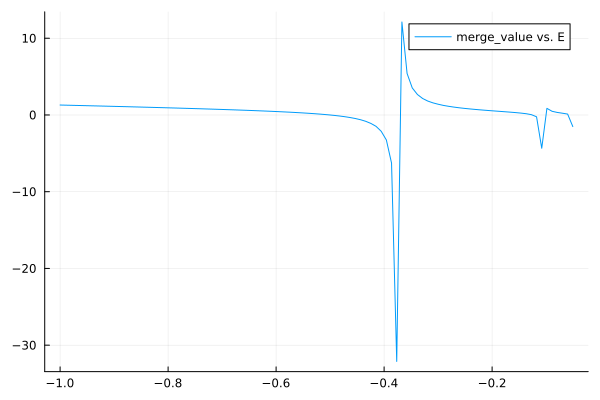

In [7]:

plot(E_grid_stru.grid, merge_value_list, label="merge_value vs. E"
)

In [ ]:
##TEST FOR EIGENVALUE PROBLEM
Z=1;
r_max= 25.0;
grid_stru= Grids.ExponentialGrid(r_max, Z);
grid=grid_stru.grid;
h_u_s1= Hydrogen.u_s1_hydrogen(grid_stru.grid);
h_u_s1_norm= MathUtils.normalize!(h_u_s1, grid);
l=0;
n=1;
E=-Z^2/(2*n^2);
v_effe =(
    Potentials.angular_potential(l, grid) .+
    Potentials.coulomb_potential(Z, grid));
r_min=grid_stru.grid[1];
u1, w1 = InitialConditions.atom_like_poly_at_r_min(r_min,l);
u_end, w_end=InitialConditions.exponential_decay_at_r_ref(r_max, E);
u_merged, merge_value, merge_ratio=OneDSchrodingerEquationSolver.solver_uniform_integer_grid(E, u1, w1, u_end, w_end, 
v_effe, grid_stru);

In [ ]:
plot(
    grid,
    u_merged,
    label="u_merged",
    xlabel="r",
    ylabel="u",
    title="u_merged and h_u_s1_norm vs. grid"
)

In [8]:
merge_value # - 1e-5

-3.9757086511826856e-13

In [9]:
merge_value # + 1e-5

-3.9757086511826856e-13

In [10]:
merge_value #0

-3.9757086511826856e-13

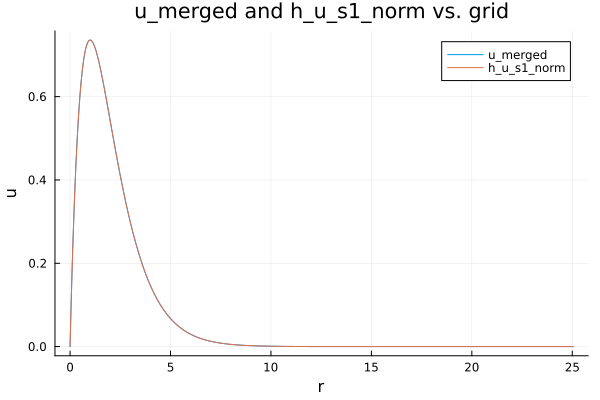

In [12]:
plot(
    grid,
    u_merged,
    label="u_merged",
    xlabel="r",
    ylabel="u",
    title="u_merged and h_u_s1_norm vs. grid"
)
plot!(grid, h_u_s1_norm, label="h_u_s1_norm")

In [ ]:
plot(
    grid,
    err,
    label="error",
    xlabel="r",
    ylabel="u",
    title="error from u_grid_i and h_u_s1 vs. grid"
)
plot!(grid, err, label="error")

In [ ]:
##TEST FOR EIGENVALUE PROBLEM

    Z=1;
    r_max= 25.0;
    grid_stru= Grids.ExponentialGrid(r_max, Z);
    grid::Vector{Float64}=grid_stru.grid;
    h_u_s1= Hydrogen.u_s1_hydrogen(grid_stru.grid);
    h_u_s1_norm= MathUtils.normalize!(h_u_s1, grid);
    l=0;
    n=1;
    E=-Z^2/(2*n^2);
    v_effe =(
        Potentials.angular_potential(l, grid) .+
        Potentials.coulomb_potential(Z, grid));

    f::Vector{Float64}= 2.0.*(v_effe .- E);
    g=zeros(Float64, size(f)[1]);
    r_min=grid_stru.grid[1];
    u1, w1 = InitialConditions.atom_like_poly_at_r_min(r_min,l);
    u_end, w_end=InitialConditions.exponential_decay_at_r_ref(r_max, E);
    u_merged, merge_value, merge_ratio=OneDSchrodingerEquationSolver.solver_uniform_integer_grid(E,u1,w1, 
    u_end,w_end,v_effe,grid_stru)
    err= ((h_u_s1_norm .- u_merged).^2.0).^0.5;
    max_err= maximum(err);
    println("max error: ", max_err);
    average_error= sum(err)/length(err);
    println("average error: ", average_error);
    @test max_err < 1.4e-11
    @test average_error < 8.1e-14

In [18]:
##TEST FOR EIGENVALUE PROBLEM

    Z=1;
    r_max= 25.0;
    grid_stru= Grids.ExponentialGrid(r_max, Z);
    grid=grid_stru.grid;
    h_u_s1= Hydrogen.u_s1_hydrogen(grid_stru.grid);
    h_u_s1_norm= MathUtils.normalize!(h_u_s1, grid);
    l=0;
    n=1;
    E=-Z^2/(2*n^2) - 1e-5;
    v_effe =(
        Potentials.angular_potential(l, grid) .+
        Potentials.coulomb_potential(Z, grid));

    f::Vector{Float64}= 2.0.*(v_effe .- E);
    turn_pnts= MathUtils.indices_of_zeros_finder(f);
    g=zeros(Float64, size(f)[1]);
    r_min=grid_stru.grid[1];
    grid_i=grid_stru.grid_i;
    dx_di=grid_stru.dx_di;
    u1, w1 = InitialConditions.atom_like_poly_at_r_min(r_min,l);
    u_end, w_end=InitialConditions.exponential_decay_at_r_ref(r_max, E);
    u_fwd_i= IntegralNumericalMethods.integrate_second_order_DE_RK4_PCABM5_on_integer_grid(grid_i,
    g,f,dx_di,
    u1,w1);
    
    u_bwd_i= reverse(IntegralNumericalMethods.integrate_second_order_DE_RK4_PCABM5_on_integer_grid(reverse(grid_i),
    g,
    reverse(f),reverse(dx_di),
    u_end,w_end));
    u_fwd_i, u_bwd_i= MathUtils.rescale_to_unity_at_turning_point!(u_fwd_i, u_bwd_i, turn_pnts[1]);
    u_merged, merge_value, merge_ratio= MathUtils.merge_solutions(u_fwd_i, u_bwd_i, 
    grid, turn_pnts[1]);
    u_merged_norm= MathUtils.normalize!(u_merged, grid);
    

6757-element Vector{Float64}:
 2.0021524145872255e-8
 4.008923972463517e-8
 6.020324419832355e-8
 8.036364435163556e-8
 1.0057054720551099e-7
 1.2082405106669347e-7
 1.4112427238818106e-7
 1.6147131892812192e-7
 1.8186529869473363e-7
 2.0230631994482756e-7
 ⋮
 1.026966691672202e-9
 9.716351450849648e-10
 9.190571896883664e-10
 8.690964125980309e-10
 8.216224758893063e-10
 7.765108264550647e-10
 7.3364248028699e-10
 6.929037162861928e-10
 6.541858486597243e-10

In [3]:
dx_di[1:10]

10-element Vector{Float64}:
 1.0022425086216066e-8
 1.0045543375657353e-8
 1.0068714991045415e-8
 1.0091940055384877e-8
 1.0115218691964101e-8
 1.0138551024355827e-8
 1.0161937176417832e-8
 1.01853772722936e-8
 1.0208871436412965e-8
 1.0232419793492777e-8

In [8]:
end_i

6757

In [ ]:
l=0;
n=1;
E=-Z^2/(2*n^2);
v_effe =(
    Potentials.angular_potential(l, grid) .+
    Potentials.coulomb_potential(Z, grid));

f::Vector{Float64}= 2.0.*(v_effe .- E);
g=zeros(Float64, size(f)[1]);
r_min=grid_stru.grid[1];
u1, w1 = InitialConditions.atom_like_poly_at_r_min(r_min,l);
u_end, w_end=InitialConditions.exponential_decay_at_r_ref(r_max, E);

u_merged, merge_value, merge_ratio=OneDSchrodingerEquationSolver.solver_uniform_integer_grid(E,u1,w1, u_end,w_end,,v_effe,grid_stru)
err= ((h_u_s1_norm .- u_merged).^2.0).^0.5;
max_err= maximum(err);
println("max error: ", max_err);
average_error= sum(err)/length(err);
println("average error: ", average_error);


max error: 1.3621568321412686e-11
average error: 8.044746461520742e-14


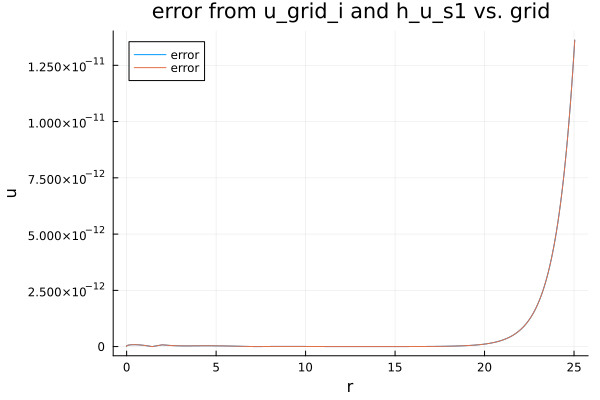

In [12]:
plot(
    grid,
    err,
    label="error",
    xlabel="r",
    ylabel="u",
    title="error from u_grid_i and h_u_s1 vs. grid"
)
plot!(grid, err, label="error")

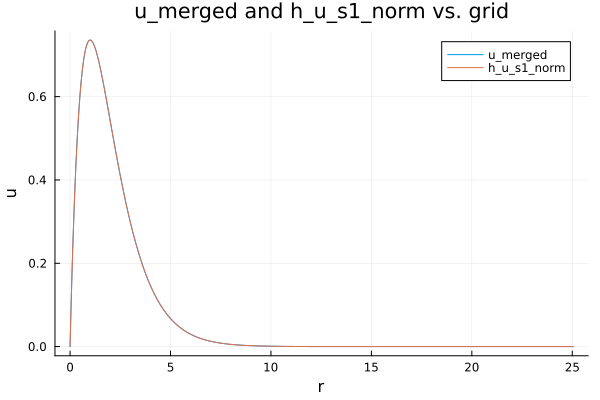

In [13]:
plot(
    grid,
    u_merged,
    label="u_merged",
    xlabel="r",
    ylabel="u",
    title="u_merged and h_u_s1_norm vs. grid"
)
plot!(grid, h_u_s1_norm, label="h_u_s1_norm")

In [ ]:
n=1;
Z=1;
E=-Z^2/(2*n^2);
v_effe =(
    Potentials.angular_potential(l, grid) .+
    Potentials.coulomb_potential(Z, grid));

f::Vector{Float64}= 2.0.*(v_effe .- E);
g=zeros(Float64, size(f)[1]);
turn_pnts= MathUtils.indices_of_zeros_finder(f);
u_fwd= IntegralNumericalMethods.integrate_second_order_DE_RK4_PCABM5_direct_initial(grid,g,f,
u1,w1);

u_bwd= reverse(IntegralNumericalMethods.integrate_second_order_DE_RK4_PCABM5_direct_initial(reverse(grid),
g,reverse(f),
u_end,w_end));

u_fwd_i= IntegralNumericalMethods.integrate_second_order_DE_RK4_PCABM5_on_integer_grid(grid_i,g,f,dx_di,
u1,w1);

u_bwd_i= reverse(IntegralNumericalMethods.integrate_second_order_DE_RK4_PCABM5_on_integer_grid(reverse(grid_i),g,
reverse(f),reverse(dx_di),
u_end,w_end));
u_fwd, u_bwd= MathUtils.rescale_abs!(u_fwd, u_bwd, turn_pnts[1]);
u_merged, merge_value, merge_ratio= MathUtils.merge_solutions(u_fwd, u_bwd, grid, turn_pnts[1]);
error= ((h_u_s1 .- u_merged).^2.0).^0.5;
max_error= maximum(error);
println("max error: ", max_error);
average_error= sum(error)/length(error);
println("average error: ", average_error);


max error: 3.9519951178235146e-7
average error: 2.418139034722081e-8


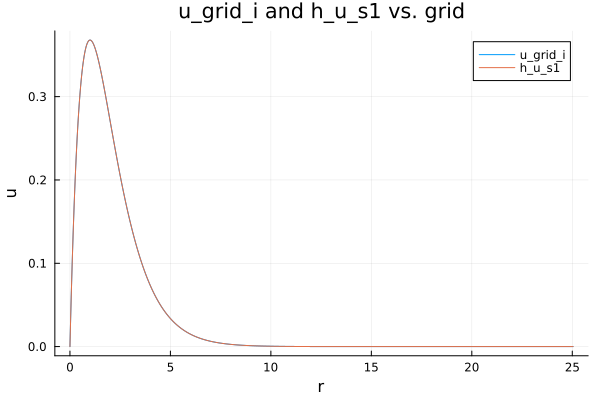

In [18]:
plot(
    grid,
    u_grid_i,
    label="u_grid_i",
    xlabel="r",
    ylabel="u",
    title="u_grid_i and h_u_s1 vs. grid"
)
plot!(grid, h_u_s1, label="h_u_s1")

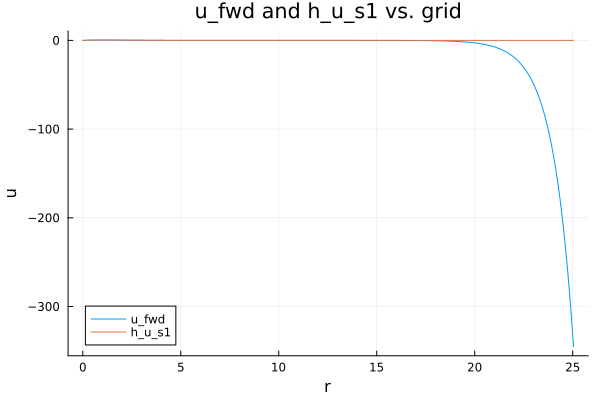

In [19]:
plot(
    grid,
    u_fwd,
    label="u_fwd",
    xlabel="r",
    ylabel="u",
    title="u_fwd and h_u_s1 vs. grid"
)
plot!(grid, h_u_s1, label="h_u_s1")

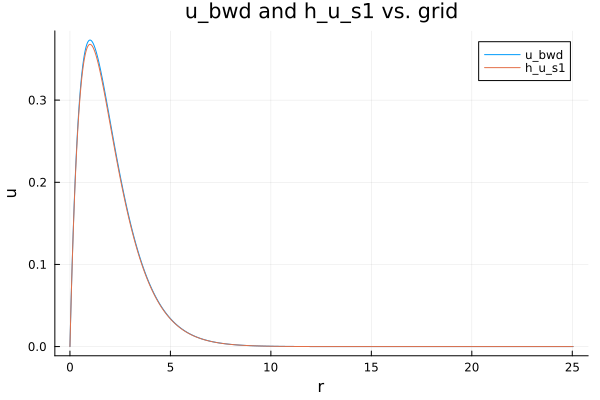

In [20]:

plot(
    grid,
    u_bwd,
    label="u_bwd",
    xlabel="r",
    ylabel="u",
    title="u_bwd and h_u_s1 vs. grid"
)
plot!(grid, h_u_s1, label="h_u_s1")

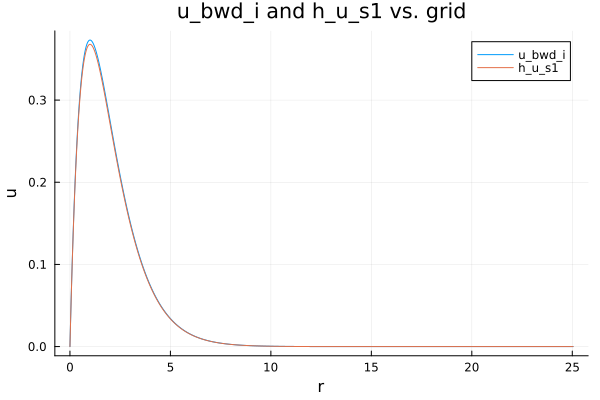

In [21]:
plot(
    grid,
    u_bwd_i,
    label="u_bwd_i",
    xlabel="r",
    ylabel="u",
    title="u_bwd_i and h_u_s1 vs. grid"
)
plot!(grid, h_u_s1, label="h_u_s1")

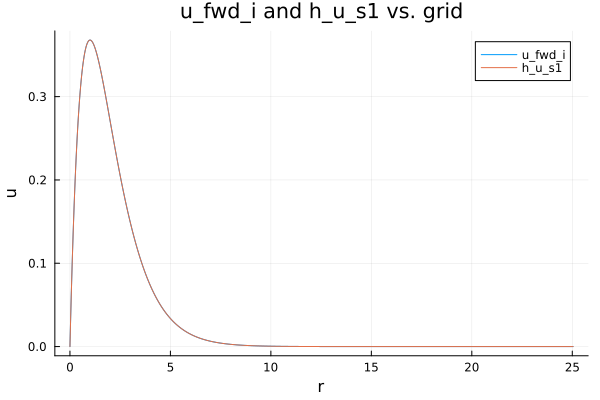

In [22]:

plot(
    grid,
    u_fwd_i,
    label="u_fwd_i",
    xlabel="r",
    ylabel="u",
    title="u_fwd_i and h_u_s1 vs. grid"
)
plot!(grid, h_u_s1, label="h_u_s1")

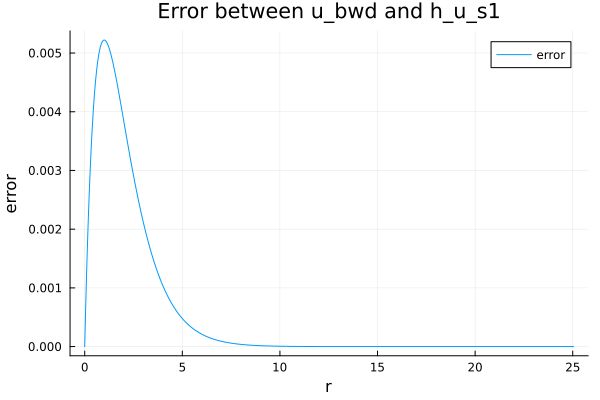

In [23]:

err = ((u_bwd .- h_u_s1).^2).^0.5

plot(
    grid,
    err,
    label="error",
    xlabel="r",
    ylabel="error",
    title="Error between u_bwd and h_u_s1"
)

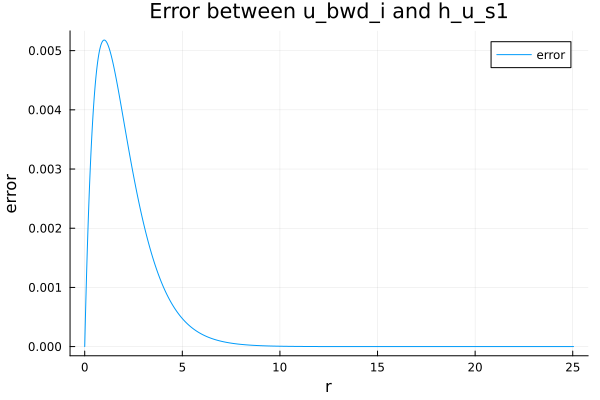

In [24]:
err = ((u_bwd_i .- h_u_s1).^2).^0.5

plot(
    grid,
    err,
    label="error",
    xlabel="r",
    ylabel="error",
    title="Error between u_bwd_i and h_u_s1"
)

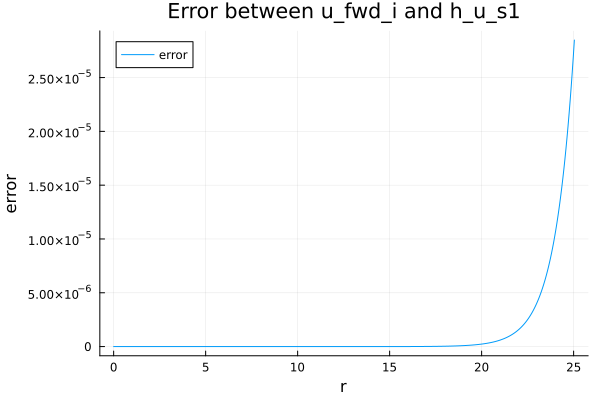

In [25]:
err = ((u_fwd_i .- h_u_s1).^2).^0.5

plot(
    grid,
    err,
    label="error",
    xlabel="r",
    ylabel="error",
    title="Error between u_fwd_i and h_u_s1"
)

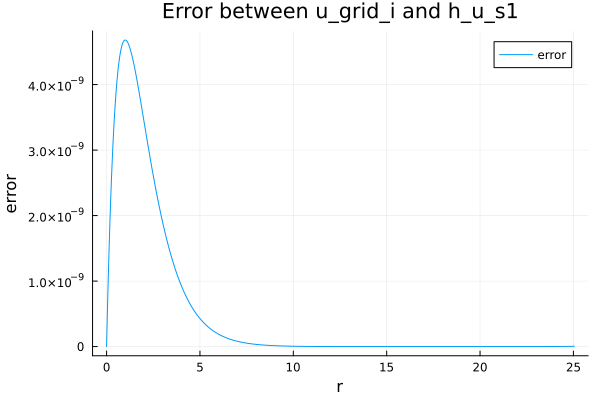

In [26]:
err = ((u_grid_i .- h_u_s1).^2).^0.5

plot(
    grid,
    err,
    label="error",
    xlabel="r",
    ylabel="error",
    title="Error between u_grid_i and h_u_s1"
)

In [16]:
u_grid_i

([1.0010888014393886e-8, 2.0044871834661333e-8, 3.0102000393098767e-8, 4.0182327082725893e-8, 5.0285905414684756e-8, 6.041278454296453e-8, 7.056302269479563e-8, 8.073667374992887e-8, 9.093379171315138e-8, 1.0115443071354871e-7  …  5.440524870806898e-10, 5.15006042719207e-10, 4.874123977997134e-10, 4.612004129593101e-10, 4.3630214678010563e-10, 4.1265271354420717e-10, 3.901901393377411e-10, 3.688552552975044e-10, 3.485915459212243e-10, 3.293450366241264e-10], -1.0844103393026217e-13, 1.0000000000008014)

In [2]:

using PDFmerger
using LaTeXStrings
using Downloads  # for file deletion
using Printf

df_dft."0"[3:end]

In [3]:
#Define parameters and produce an exponential grid.
r_max::Float64=50;#Max radius of space grid.
Z::Int64=6; #Atomic number, also used as the charge of coulomb potential.

In [4]:
using JSON3

In [5]:
file= open(joinpath(dirname(@__FILE__),"../data/atom_number_name.json"));
atom_number_name= JSON3.read(file)[Z];

In [6]:
atom_number_name

"Carbon"

In [7]:
df_dft=DataFrame(CSV.File(joinpath("/home/arturo_hernandez/Downloads/nist_dft_tables/dft_Z_$Z/$Z.csv")));

In [8]:
df_dft

Row,Column1,0,1,2,3,4
,Int64,String7,String15,String31,String31,String15
1,0,Energy,LDA,LSD,RLDA,ScRLDA
2,1,Etot =,-37.425749,-37.470031,-37.434171,-37.434170
3,2,Ekin =,37.190391,37.242662,37.215681,37.213317
4,3,Ecoul =,17.627997,17.722784,17.632308,17.631889
5,4,Eenuc =,-87.515412,-87.646436,-87.559852,-87.557199
6,5,Exc =,-4.728724,-4.789041,-4.722308,-4.722177
7,6,1s,-9.947718,-9.940546-9.905802,-9.945976,-9.946149
8,7,2s,-0.500866,-0.531276-0.435066,-0.501081,-0.501090
9,8,2p,-0.199186,-0.227557-0.139285,-0.199322-0.198996,-0.199111


In [ ]:

#grid definition
grid_stru= Grids.ExponentialGrid(r_max, Z);
N=grid_stru.N;
print("grid size ", N)

grid size 7835

In [10]:
#Initialization of potentials and energies

#Initializing coulomb potential due to nuclei charge.
V_colu::Vector{Float64}= Potentials.coulomb_potential(Z, grid_stru.grid);
#Initializing Hartree potential due to electron density. 
V_hartree::Vector{Float64}=zeros(Float64, N);
#Initializing exchange potential.
V_x::Vector{Float64}=zeros(Float64, N);
#Initializing correlation potential.
V_c::Vector{Float64}=zeros(Float64, N);
#Initializing energy exchange potential.
E_xp::Vector{Float64}=zeros(Float64, N);
#Initializing energy correlation potential.
E_cp::Vector{Float64}=zeros(Float64, N);
#Initializing exchange + correlation potential.
V_xcp::Vector{Float64}=zeros(Float64, N);
#Initializing the density.
density_in::Vector{Float64}= zeros(Float64, N);
#Initializing total energy
E_total::Float64=1.0;
#Initializing total energy step before
E_total_before::Float64=2.0;
#Initializing energy from energy eigenvalues
E_eigen::Float64=0.0;
#Initializing exchange correlation potential value after integral
V_xc::Float64= 0.0;
#Initializing Hartree energy
E_hartree::Float64= 0.0;
#Initializing exchange energy
E_x::Float64= 0.0;
#Initializing correlation enrgy
E_c::Float64= 0.0;

E_kinetic::Float64= 0.0;
#Initializing basis set data structure
basis= AtomBasisSet.init_atom_basis_set(Z, grid_stru.grid);

In [11]:
for i_orbi in basis.orbitals
    println(i_orbi.name)
    println(i_orbi.E)
end

1s
-18.0
2s
-4.5
2p
-4.5


In [12]:

V_dens_in= V_hartree .+ V_x .+ V_c;
#Energy minimization loop 
while abs(E_total - E_total_before) > 10.0e-8
    E_eigen=0.0;
    #Loop over every orbital to solve independent particle Schrodinger equation.
    for i_orbi in basis.orbitals
        #println(i_orbi.name)
        #angular potential for l orbital
        V_angu= Potentials.angular_potential(i_orbi.l, grid_stru.grid);
        #Assemble effective potential.
        #V_effe= V_colu .+ V_angu .+ V_hartree .+ V_x .+ V_c;
        V_effe= V_colu .+ V_angu .+ V_dens_in;
        V_effe_max= maximum(V_effe)
        V_effe_min= minimum(V_effe)
        #println(V_effe_max);
        #println(V_effe_min);
        energy_interval= EigenvalueFinders.guess_energy_interval(i_orbi.E, V_effe_max, V_effe_min);
        #println(E_intervals);
        E_grid= Grids.uniform_grid(energy_interval[1], energy_interval[2], 300); #List with the energy grid points.

        E_intervals= EigenvalueFinders.find_eigenvalue_intervals(E_grid, V_effe, grid_stru,
                    InitialConditions.atom_exponential_grid,
                        OneDSchrodingerEquationSolver.solver_exponential_grid, numb_inter=1);
        #println(E_intervals);
        #print("here ")
        u_temp, ei_temp= EigenvalueFinders.illinois_eigenvalue_finder(E_intervals[1], V_effe, 
        grid_stru,InitialConditions.atom_exponential_grid, 
        OneDSchrodingerEquationSolver.solver_exponential_grid ,
        l=i_orbi.l);
        #Update eigenvalue and eigenfunction in the basis set data structure.
        i_orbi.E=ei_temp;
        i_orbi.u=u_temp;
        E_eigen+= i_orbi.occu*ei_temp;
        #println(i_orbi.E)
        #println("--------------------------------")

    end
    #Update E_total_before from the E_total from the previous step.
    E_total_before= float(E_total);
    V_no_kinetic= V_colu .+ V_hartree .+ V_x .+ V_c;
    #Calculate density with new basis set.
    density_out= Density.calculate_density(basis);
    #Smooth the density with linear mixing (combination) of the previous and current densities.
    density_in= Density.linear_mixing(density_in, density_out, alpha=0.110);

    #Solve Poisson equation to find the new Hartree potential.
    V_hartree= OneDPoissonEquationSolver.solver_exponential_grid(Z, density_in, grid_stru);
    #Calculate new exchange and correlation potentials.
    V_x, E_xp, V_c, E_cp= ExchangeCorrelation.potentials(density_in);
    #Add exchange and correlation potentials.
    V_xcp= V_x .+ V_c;
    #Integrals to calculate energy components.
    E_kinetic= E_eigen - 4.0*pi*MathUtils.energy_integral_exponential_grid(grid_stru, density_in, V_no_kinetic);
    #V_xc= 4.0*pi*MathUtils.energy_integral_exponential_grid(grid_stru, density_in, V_xcp)

    E_hartree= 0.5*4.0*pi*MathUtils.energy_integral_exponential_grid(grid_stru, density_in, V_hartree);

    E_x= 4.0*pi*MathUtils.energy_integral_exponential_grid(grid_stru, density_in, E_xp);

    E_c= 4.0*pi*MathUtils.energy_integral_exponential_grid(grid_stru, density_in, E_cp);
    E_colu= 4.0*pi*MathUtils.energy_integral_exponential_grid(grid_stru, density_in, V_colu);
    #Calculate total energy.
    E_total= E_kinetic + E_hartree + E_x + E_c + E_colu;
    V_dens_out= V_hartree .+ V_x .+ V_c;
    V_dens_in= Density.linear_mixing(V_dens_in, V_dens_out, alpha=0.210);
    #println(E_total)
    #println("*****************************************")

end
println("Ekin ", E_kinetic)
println("Ecoul ", E_hartree)
println("Exc ", (E_x + E_c))
println("Etot ", E_total)
pred_energy_dict= Dict("Ekin"=> E_kinetic, "Exc"=>(E_x + E_c),
"Ecoul"=>E_hartree, "Etot"=>E_total)
for i_orbi in basis.orbitals
    merge!(pred_energy_dict, Dict(i_orbi.name => i_orbi.E))
    println(i_orbi.name)
    println(i_orbi.E)
end



Ekin 37.19236083319477
Ecoul 17.63071209347793
Exc -4.729163687961755
Etot -37.4257488296754
1s
-9.949687996629653
2s
-0.5028475590551488
2p
-0.20111721109201647


In [ ]:
# Initialize arrays
names = String[]
E_pred = Float64[]
E_targ = Float64[]

for (key, value) in pred_energy_dict
    push!(names, key)
    push!(E_pred, value)
    push!(E_targ, energy_target[key])
end

# Compute absolute differences and percentage error
E_diff = abs.(E_pred .- E_targ)
Perc_error = E_diff ./ E_targ

# Create table rows as vectors of strings
atom_header = ["$(basis.Name)", "E in Hartree", "", "", ""]
header = ["Name", "E NIST", "E pred", "|ΔE|", "|ΔE|/E NIST"]
data_rows = [atom_header,header]
for (n, targ, pred, diff, perc) in zip(names, E_targ, E_pred, E_diff, Perc_error)
    # Format each value nicely:
    push!(data_rows, [ n,
                        @sprintf("%10.6f", targ),
                        @sprintf("%10.6f", pred),
                        @sprintf("%8.6f", diff),
                        @sprintf("%12.6f", perc)
                      ])
end

# ----------------------------
# Define table layout parameters
# ----------------------------
nrows = length(data_rows)     # number of rows (including header)
ncols = length(header)        # number of columns

# Define the horizontal boundaries for columns (you can adjust these widths)
# For example, here we set 5 columns with different widths in arbitrary units.
col_widths = [1.5, 2.5, 2.5, 2, 3]  # relative widths for each column
# Compute cumulative positions
col_x = [0.0]
for w in col_widths
    push!(col_x, col_x[end] + w)
end
total_width = col_x[end]

# Each row will have a fixed height:
row_height = 1.0
total_height = nrows * row_height

# ----------------------------
# Create the plot that will serve as the table "page"
# ----------------------------
p_table = plot(xlim=(0, total_width), ylim=(0, total_height),
    framestyle = :none,
    legend = false,
    grid = false,
    xticks = false,
    yticks = false,
    size = (800, Int(50 * nrows))  # adjust size as needed
)
# Add the title at the top center


# Draw horizontal lines (rows)
for i in 0:nrows
    plot!([0, total_width], [i * row_height, i * row_height], color = :black, lw = 1)
end

# Draw vertical lines (columns)
for x in col_x
    plot!([x, x], [0, total_height], color = :black, lw = 1)
end

# Annotate each cell with the cell text (we assume center alignment in each cell)
for (i, row) in enumerate(reverse(data_rows))  # reverse so that first row is at the top
    y_center = (i - 0.5) * row_height  # center of the row cell
    for j in 1:ncols
        # Calculate the x-center for column j (between col_x[j] and col_x[j+1])
        x_center = (col_x[j] + col_x[j+1]) / 2
        text_str = row[j]
        annotate!(p_table, x_center, y_center, text(text_str, 12, :center))
    end
end

# Save the table as a PDF
table_page_file="table_page.pdf"
savefig(p_table, table_page_file)

orbital_files = String[]

for i_orbi in basis.orbitals
    orbi_eigen = @sprintf("%.4f", i_orbi.E)
    plot_str = "Orbital $(i_orbi.name) eigen energy $orbi_eigen"

    p_orbi = plot(
        grid_stru.grid_i, i_orbi.u,
        title = plot_str,
        xlabel = "i", ylabel = "u(r(i))",
        legend = false
    )

    orbital_file = "orbital_$(i_orbi.name).pdf"
    savefig(p_orbi, orbital_file)
    push!(orbital_files, orbital_file)
end



all_files = [table_page_file; orbital_files...]
final_pdf = pdf_output#"file.pdf"  # Final output file
merge_pdfs(all_files, final_pdf)



for f in all_files
    try
        rm(f)
    catch e
        @warn "Could not delete file $f" exception=(e, catch_backtrace())
    end
end

#println("✅ Successfully created $final_pdf with table and orbital plots!")

✅ Successfully created /home/arturo_hernandez/Desktop/physics_coding_projects/julia/SchrodingerEquationSolver/pdf_outputs/2.pdf with table and orbital plots!
